### 1. Configuracao ambiente e importacao de bibliotecas

In [ ]:
# Importar bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações do seaborn
sns.set(style="whitegrid")

### Carregar a base de dados do Titanic

In [6]:
from google.colab import drive
drive.mount('/content/drive')

# O caminho pelo local correto do arquivo no seu Google Drive
file_path = '/content/drive/MyDrive/titanic_datasetLF.csv'

# Ler CSV com pandas
df = pd.read_csv(file_path)

# Mostrar as primeiras linhas
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Exploracao dos dados

In [7]:
# Ver informações gerais
df.info()

# Estatísticas descritivas
df.describe()

# Checar valores nulos
df.isnull().sum()

# Visualizar colunas
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

### Limpeza dos dados

In [ ]:
# Preencher valores nulos (exemplo: idade média)
df['Age'].fillna(df['Age'].mean(), inplace=True)

# Preencher valores nulos da coluna 'Embarked' com o modo
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

### Análise exploratória visual

#### Distribuição de sobreviventes

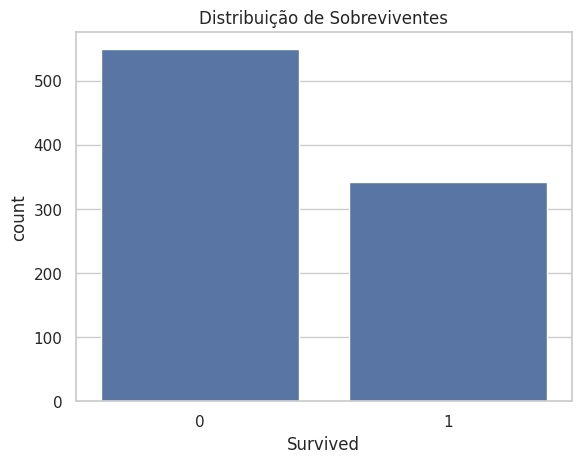

In [9]:
sns.countplot(x='Survived', data=df)
plt.title('Distribuição de Sobreviventes')
plt.show()

#### Comparar sobrevivência por sexo

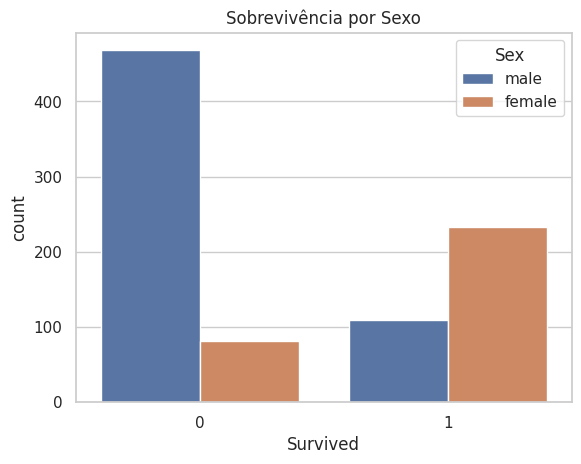

In [10]:
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title('Sobrevivência por Sexo')
plt.show()

#### Comparar sobrevivência por classe

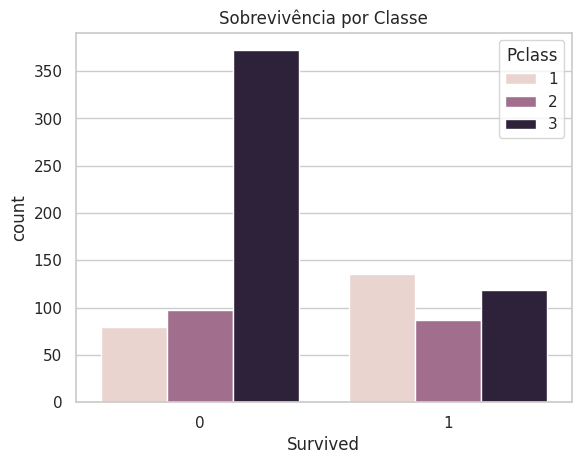

In [11]:
sns.countplot(x='Survived', hue='Pclass', data=df)
plt.title('Sobrevivência por Classe')
plt.show()

#### Distribuição de idade

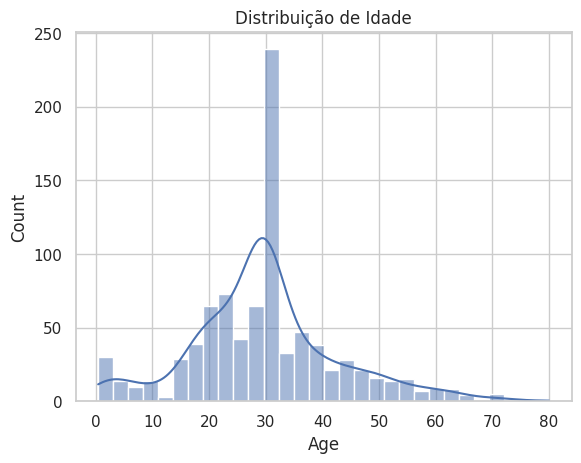

In [12]:
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Distribuição de Idade')
plt.show()

#### Sobrevivência por faixa de idade

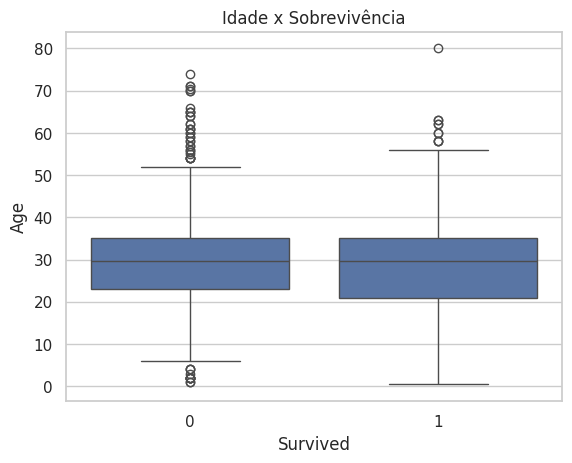

In [13]:
sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Idade x Sobrevivência')
plt.show()

#### Análise de correlações

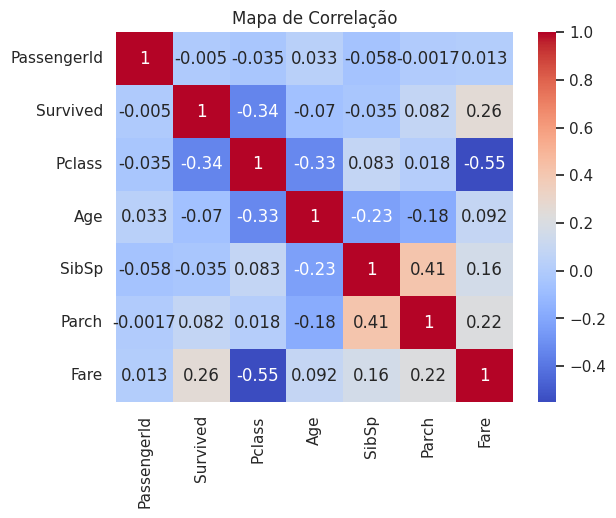

In [15]:
# Correlação entre variáveis numéricas
# Selecionar apenas colunas numéricas antes de calcular a correlação
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Mapa de Correlação')
plt.show()

### Insights possíveis

* Mulheres tiveram maior taxa de sobrevivência que homens.

* Passageiros da 1ª classe sobreviveram mais que os das classes inferiores.

* Idade pode influenciar a sobrevivência (crianças com maior chance).

* Número de irmãos/cônjuges (SibSp) e pais/filhos (Parch) também podem ter impacto.




###